In [41]:
from langgraph.graph import StateGraph,START ,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Literal,Annotated
from dotenv import load_dotenv
import operator
from langchain_core.messages import SystemMessage, HumanMessage

In [22]:
generator_llm = ChatOpenAI(model='gpt-4o')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o')

In [23]:
from pydantic import BaseModel,Field

class TweetEvaluationSchema(BaseModel):
    evaluation: Literal['approved', 'need_improvement'] = Field(description="Whether the generated tweet is approved or needs improvement")
    feedback: str = Field(description="Detailed feedback on the generated tweet, especially if it needs improvement")
    score: int = Field(... , ge = 0 , le = 5, description="total score from rubric (0 to 5)")

In [24]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluationSchema)

In [42]:
#state
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved', 'need_improvement']
    feedback: str
    iteration: int
    max_iterations: int

    tweet_history: Annotated[list[str],operator.add]
    feedback_history: Annotated[list[str],operator.add]


In [43]:
def generate_tweet(state: TweetState):

    #prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_llm.invoke(messages).content

    return {'tweet': response, 'tweet_history': [response]}

def generate_evaluation(state:TweetState):

    #prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
] 

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}


def optimize_tweet(state:TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm(messages).content
    iteration = state['iteration'] + 1
    return {'tweet': response, 'tweet_history': [response]}




   


In [44]:
def route_evaluation(state:TweetState):

    if state["evaluation"] == "approved" or state["iteration"] >= state["max_iterations"]:
        return "approved"
    else:
        return "need_improvement"

In [45]:
#graph
graph = StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node("evaluate",generate_evaluation)
graph.add_node("optimize",optimize_tweet)



graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {
    'approved': END,
    'need_improvement': 'optimize'
})
graph.add_edge('optimize','evaluate')
graph.add_edge('evaluate',END)

workflow = graph.compile()

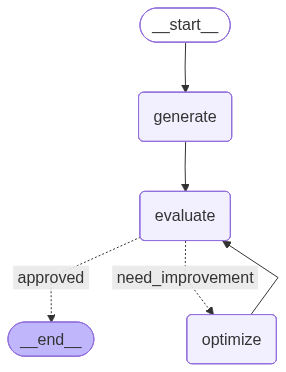

In [46]:
workflow

In [47]:
initial_state = {
    "topic": "Indian Railways",
    "iteration": 1,
    "max_iterations": 5
}
result = workflow.invoke(initial_state)

In [48]:
result

{'topic': 'Indian Railways',
 'tweet': 'Boarded an Indian train and immediately made three friends, four aunts, and a guy who’s convinced I’m his long-lost cousin. Meanwhile, my seat remains a mystery wrapped in an enigma covered in a thousand chai cups. 🚂 #IndianRailwaysLogic',
 'evaluation': 'approved',
 'feedback': 'This tweet is a delightfully original take on the experience of traveling on an Indian train, painting a vivid picture of social interactions and the chaos typical of such journeys. The humor is relatable and evokes a smile with the exaggeration of making new friends and the mystery of a missing seat. It manages to be punchy while keeping an engaging narrative flow, making it likely to resonate with others and be shared. The format is spot on, fitting well within the character limit, and it avoids cliché endings, keeping the humor intact.',
 'iteration': 1,
 'max_iterations': 5,
 'tweet_history': ['Boarded an Indian train and immediately made three friends, four aunts, a

In [49]:
initial_state = {
    "topic": "Indian food",
    "iteration": 1,
    "max_iterations": 5
}
result = workflow.invoke(initial_state)

In [50]:
result

{'topic': 'Indian food',
 'tweet': 'My relationship with Indian food is like every Netflix show: spice, drama, suspense, and me questioning all my life choices as the credits (and the heartburn) roll in. 🍛🔥😅',
 'evaluation': 'approved',
 'feedback': 'This tweet uses a clever analogy that links the experience of indulging in Indian food with binge-watching Netflix shows, creating a relatable and humorous context. The imagery of "spice, drama, suspense" effectively captures the essence of both experiences, while the mention of questioning life choices and heartburn adds a personal touch that resonates well. It\'s fresh and original, combining popular culture with food in a way that\'s engaging. The tweet is also concise and punchy, making it easy to read and share, enhancing its potential for virality.',
 'iteration': 1,
 'max_iterations': 5,
 'tweet_history': ['My relationship with Indian food is like every Netflix show: spice, drama, suspense, and me questioning all my life choices as 

In [53]:
initial_state = {
    "topic": "Egdbeq",
    "iteration": 1,
    "max_iterations": 5
}
result = workflow.invoke(initial_state)

In [54]:
result

{'topic': 'Egdbeq',
 'tweet': "Tried Egdbeq for the first time and now my phone auto-corrects everything to existential dread. If I don't post for a while, send coffee and cats to my thought bunker.",
 'evaluation': 'approved',
 'feedback': 'This tweet excels in originality, as the concept of an auto-correct that symbolizes existential dread is a fresh take. It is humorous, providing a relatable sense of despair while maintaining a lighthearted tone, which makes it enjoyable. The imagery of needing coffee and cats to cope adds a quirky touch that enhances its punchiness. In terms of format, the tweet is concise and well-structured, falling comfortably within the character limit and avoiding generic endings. Overall, these factors contribute to its strong potential for virality, making it highly shareable.',
 'iteration': 1,
 'max_iterations': 5,
 'tweet_history': ["Tried Egdbeq for the first time and now my phone auto-corrects everything to existential dread. If I don't post for a whil

In [55]:
for tweet in result['tweet_history']:
    print(tweet)

Tried Egdbeq for the first time and now my phone auto-corrects everything to existential dread. If I don't post for a while, send coffee and cats to my thought bunker.
